# NB09a: Dietrich RF Baseline + Ablation v17

> Copyright (C) 2024-2026 Marco Heinzen - SPDX-License-Identifier: AGPL-3.0-or-later
> Part of the Master Thesis "Building Damage Assessment with Multimodal Satellite Time Series and Machine Learning in the Russia-Ukraine War 2022-2026"
> Code hosted at https://github.com/marcoheinzen/bda
> Parts of this code were written or improved with the assistance of Claude (Anthropic); all other code, and the concept, research, architecture, design, execution, testing and validation throughout, are the author's work.


Systematic ML experiments. GroupKFold as headline metric.
Each R-cell loads its OWN parquet. S0 loads only building metadata + shared eval.

**Parquet mapping:**
- R0, R1, R3-R5, R7: `bda_product_prepost` (period-aggregated, wide)
- R0a: `bda_block_stats_card` (Dietrich 3-month blocks)
- R0b, R2: `bda_rolling_roll{N}` (rolling window stats, one per window size)

In [1]:
# @title CELL 3: NB09a CONFIG
TIER_SELECTION = [0,1,2]
CITY_FILTER = None
CITY_SELECTION = None
REQUIRE_UNOSAT = True
RANDOM_STATE = 42
N_FOLDS = 5


In [2]:
# @title CELL 4: LOAD GLOBAL SETUP
import platform, os, json
if platform.system() == "Windows":
    _setup = r"F:\PROJECTS\masterthesis\gdrive\masterthesis\notebooks\global_setup.py"
elif os.path.exists("/content/drive_f"):
    _setup = "/content/drive_f/masterthesis/notebooks/global_setup.py"
else:
    _setup = "/mnt/f/PROJECTS/masterthesis/gdrive/masterthesis/notebooks/global_setup.py"
with open(_setup) as f:
    exec(f.read())


BDA GLOBAL SETUP
Started: 2026-04-12 23:02:13
Python: 3.12.12

[1/7] Directory Structure
----------------------------------------------------------------------


/home/alpineobotics/miniconda3/envs/bda/lib/python3.12/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


  GDrive (G:):       /content/drive_f/masterthesis OK
  GDrive (F:):       /content/drive_f/masterthesis OK
  Local data (G:):   /content/masterthesis_local/data OK
  Data stack (F:):   /mnt/f/PROJECTS/masterthesis/data_stack OK

  TIER_SELECTION: [0, 1, 2]
  CITY_SELECTION: None (tier filter)
  REQUIRE_UNOSAT: True
  CITIES_TO_PROCESS: 21 cities

[2/7] Credentials
----------------------------------------------------------------------
  Copernicus: inf***
  OpenTopography: OK
  Earthdata: marcoheinzen

[3/7] Python Packages
----------------------------------------------------------------------


<string>:536: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.



  Already installed: 23
  Newly installed:   0
  Failed:            0

[4/7] Global Imports & Configuration
----------------------------------------------------------------------
  All imports loaded

[5/7] Processing Config & SNAP
----------------------------------------------------------------------
  GPT: Usage:
  Temporal baseline: 10-24 days
  Wavelength: 0.0555

[6/7] GPU Status
----------------------------------------------------------------------
  CUDA available: NVIDIA GeForce RTX 2070 SUPER
    CUDA version: 12.8

[7/7] Disk Space
----------------------------------------------------------------------
  GDrive (G:)     913.0/7452.0 GB (6539.0 GB free)
  GDrive (F:)     1177.0/3726.0 GB (2549.0 GB free)
  Local data      11361.5/14901.9 GB (3540.3 GB free)
  Data stack      1177.0/3726.0 GB (2549.0 GB free)
  WSL ext4        88.9/1006.9 GB (866.7 GB free)

GLOBAL SETUP COMPLETE
  Torch device: cuda
  Cities: 21, CITY=Avdiivka
  Functions: load_aoi(), load_aoi_gdf(), load_aoi_

# CELL S0: LOAD BUILDINGS + SHARED EVAL INFRASTRUCTURE


In [3]:
# @title CELL S0: NB09a LOAD BUILDINGS + SHARED EVAL
import sys, importlib, re, gc, time
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.model_selection import GroupKFold, StratifiedKFold
from sklearn.metrics import (roc_auc_score, f1_score, precision_score,
                             recall_score, precision_recall_curve, roc_curve)
from sklearn.impute import SimpleImputer
from sklearn.base import clone
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")

print("=" * 70)
print("CELL S0: NB09a LOAD BUILDINGS + SHARED EVAL")
print("=" * 70)

if str(NOTEBOOKS_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOKS_DIR))

# load building metadata (per-tier)
_tiers = TIER_SELECTION if isinstance(TIER_SELECTION, list) else [0, 1, 2]
df_bldg = load_tier_parquets(PARQUET_BUILDINGS_TIER_FMT, _tiers)
CITIES_TO_PROCESS, _battle_dates = resolve_cities(
    tier_selection=TIER_SELECTION,
    city_selection=[CITY_FILTER] if isinstance(CITY_FILTER, str) else CITY_FILTER,
    require_unosat=REQUIRE_UNOSAT,
)
df_bldg = df_bldg[df_bldg['city'].isin(CITIES_TO_PROCESS)].copy()
df_bldg = df_bldg[df_bldg['damage_binary'] >= 0].copy()
print(f"  Cities: {len(CITIES_TO_PROCESS)}")
print(f"  Buildings: {len(df_bldg)} (damaged={int((df_bldg['damage_binary']==1).sum())}, undamaged={int((df_bldg['damage_binary']==0).sum())})")

TARGET_COL = 'damage_binary'
EXPERIMENT_LOG = {}
DIETRICH_PAPER = {'auc': 0.813, 'f1': 0.749, 'precision': 0.671, 'recall': 0.846}


def load_and_merge(parquet_fmt, **kwargs):
    """Load per-tier parquets and merge with building labels.
    parquet_fmt: tier fmt string (e.g. PARQUET_PREPOST_TIER_FMT) or Path for legacy.
    Extra kwargs passed to load_tier_parquets (e.g. window=7)."""
    if isinstance(parquet_fmt, Path) and parquet_fmt.exists():
        df = pd.read_parquet(parquet_fmt)  # legacy single-file fallback
    else:
        df = load_tier_parquets(str(parquet_fmt), _tiers, **kwargs)
    df = df[df['city'].isin(CITIES_TO_PROCESS)].copy()
    if TARGET_COL not in df.columns:
        df = df.merge(df_bldg[['building_id', 'city', TARGET_COL]].drop_duplicates(),
                      on=['building_id', 'city'], how='inner')
    df = df[df[TARGET_COL] >= 0].copy()
    return df


def evaluate_groupkfold(clf, X, y, groups, experiment_name, n_folds=N_FOLDS, needs_scaling=False):
    n_cities = len(np.unique(groups))
    n_folds_actual = min(n_folds, n_cities)
    if n_folds_actual < 2:
        print(f"    SKIP {experiment_name}: only {n_cities} cities")
        return None

    gkf = GroupKFold(n_splits=n_folds_actual)
    y_proba_oof = np.full(len(y), np.nan)
    fold_aucs = []

    for fold_idx, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups)):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        if needs_scaling:
            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_test = scaler.transform(X_test)
        clf_copy = clone(clf)
        clf_copy.fit(X_train, y_train)
        proba = clf_copy.predict_proba(X_test)[:, 1] if hasattr(clf_copy, 'predict_proba') else 1.0 / (1.0 + np.exp(-clf_copy.decision_function(X_test)))
        y_proba_oof[test_idx] = proba
        if len(np.unique(y_test)) > 1:
            fold_aucs.append(roc_auc_score(y_test, proba))

    valid = ~np.isnan(y_proba_oof)
    y_v, p_v = y[valid], y_proba_oof[valid]
    pred_v = (p_v >= 0.5).astype(int)
    result = {
        'experiment': experiment_name,
        'auc_groupkfold': roc_auc_score(y_v, p_v),
        'f1_groupkfold': f1_score(y_v, pred_v),
        'precision': precision_score(y_v, pred_v, zero_division=0),
        'recall': recall_score(y_v, pred_v, zero_division=0),
        'fold_aucs': fold_aucs,
        'auc_mean': np.mean(fold_aucs), 'auc_std': np.std(fold_aucs),
        'n_features': X.shape[1], 'n_buildings': len(y), 'n_cities': len(np.unique(groups)),
        'y_true': y_v.copy(), 'y_proba': p_v.copy(), 'groups': groups[valid].copy(),
    }
    EXPERIMENT_LOG[experiment_name] = result
    print(f"    {experiment_name:40s}: AUC={result['auc_groupkfold']:.3f} "
          f"(+/-{result['auc_std']:.3f})  F1={result['f1_groupkfold']:.3f}  "
          f"P={result['precision']:.3f}  R={result['recall']:.3f}")
    return result


def prepare_features(df, feat_cols):
    avail = [c for c in feat_cols if c in df.columns]
    if len(avail) < 2:
        return None
    df_valid = df[df[TARGET_COL] >= 0].copy()
    nan_col_mask = df_valid[avail].isna().all()
    clean = [c for c in avail if not nan_col_mask[c]]
    if len(clean) < 2:
        return None
    imp = SimpleImputer(strategy='median')
    X = imp.fit_transform(df_valid[clean].values)
    y = df_valid[TARGET_COL].values
    groups = df_valid['city'].values
    return X, y, groups, clean


print("  Shared: load_and_merge(), evaluate_groupkfold(), prepare_features()")
print("  EXPERIMENT_LOG: global registry")



# ---- RESULT REGISTRY (for NB13 consolidation) ----
from bda_results import ResultRegistry
registry = ResultRegistry(RESULTS_ROOT, notebook='NB09a')

def log_result(res, cell_id='', parquet_name='', feature_set_name='',
               classifier_name='RF-200', feature_cols=None, note='', tags=None):
    if res is None:
        return
    registry.log_experiment(
        cell_id=cell_id,
        experiment_name=res['experiment'],
        parquet_name=parquet_name,
        tier_selection=TIER_SELECTION if isinstance(TIER_SELECTION, list) else [0,1,2],
        classifier_name=classifier_name,
        classifier_params=RF_PARAMS if classifier_name == 'RF-200' else {},
        feature_set_name=feature_set_name,
        feature_cols=feature_cols,
        cv_method='GroupKFold',
        n_folds=N_FOLDS,
        imputation='median',
        y_true=res.get('y_true'),
        y_proba=res.get('y_proba'),
        groups=res.get('groups'),
        note=note,
        tags=tags or [],
    )

# ---- OUTPUT + SAVE HELPERS ----
import matplotlib.pyplot as plt
from datetime import datetime as _dt

OUT_DIR = RESULTS_ROOT / 'nb09a'
OUT_DIR.mkdir(parents=True, exist_ok=True)

def save_result(data, name, cell_id, fmt='csv'):
    cell_dir = OUT_DIR / cell_id
    cell_dir.mkdir(parents=True, exist_ok=True)
    ts = _dt.now().strftime('%Y%m%d_%H%M%S')
    if fmt == 'csv' and isinstance(data, pd.DataFrame):
        path = cell_dir / f"{name}_{ts}.csv"
        data.to_csv(path, index=False)
    elif fmt == 'json':
        path = cell_dir / f"{name}_{ts}.json"
        import json as _j
        with open(path, 'w') as fh:
            _j.dump(data, fh, indent=2, default=str)
    else:
        raise ValueError(f"Unknown fmt={fmt}")
    print(f"  Saved: {path.relative_to(OUT_DIR)} ({path.stat().st_size / 1024:.1f} KB)")
    return path

def save_fig(fig, name, cell_id, dpi=150):
    cell_dir = OUT_DIR / cell_id
    cell_dir.mkdir(parents=True, exist_ok=True)
    ts = _dt.now().strftime('%Y%m%d_%H%M%S')
    path = cell_dir / f"{name}_{ts}.png"
    fig.savefig(path, dpi=dpi, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"  Plot: {path.relative_to(OUT_DIR)}")
    return path

print(f"  Output: {OUT_DIR}")
print(f"  Helpers: load_and_merge(), evaluate_groupkfold(), prepare_features(), save_result(), save_fig()")


CELL S0: NB09a LOAD BUILDINGS + SHARED EVAL
  load_tier_parquets: 3 tiers, 907371 rows
  Cities: 21
  Buildings: 598595 (damaged=7332, undamaged=591263)
  Shared: load_and_merge(), evaluate_groupkfold(), prepare_features()
  EXPERIMENT_LOG: global registry
  ResultRegistry: /content/drive_f/masterthesis/results/registry (run_id=20260412_230345)
  Output: /content/drive_f/masterthesis/results/nb09a
  Helpers: load_and_merge(), evaluate_groupkfold(), prepare_features(), save_result(), save_fig()


# CELL H: CLASSIFIER PARAMS + HELPERS


In [4]:
# @title CELL H: CLASSIFIER PARAMS + HELPERS
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
                               GradientBoostingClassifier)

RF_PARAMS = {'n_estimators': 200, 'min_samples_leaf': 3, 'random_state': RANDOM_STATE,
             'n_jobs': -1, 'class_weight': 'balanced'}

CLASSIFIERS = {
    'RF-200': RandomForestClassifier(**RF_PARAMS),
    'ExtraTrees': ExtraTreesClassifier(n_estimators=200, min_samples_leaf=3,
                                        random_state=RANDOM_STATE, n_jobs=-1, class_weight='balanced'),
    'GBM': GradientBoostingClassifier(n_estimators=200, max_depth=5, learning_rate=0.1,
                                       random_state=RANDOM_STATE),
}

# add LightGBM + XGBoost if available
try:
    from lightgbm import LGBMClassifier
    CLASSIFIERS['LightGBM'] = LGBMClassifier(n_estimators=200, max_depth=7, learning_rate=0.1,
                                              random_state=RANDOM_STATE, n_jobs=-1, verbose=-1,
                                              is_unbalance=True)
except ImportError:
    print("  LightGBM not available")

try:
    from xgboost import XGBClassifier
    CLASSIFIERS['XGBoost'] = XGBClassifier(n_estimators=200, max_depth=7, learning_rate=0.1,
                                            random_state=RANDOM_STATE, n_jobs=-1, verbosity=0,
                                            scale_pos_weight=1, use_label_encoder=False, eval_metric='logloss')
except ImportError:
    print("  XGBoost not available")

print(f"  Classifiers: {list(CLASSIFIERS.keys())}")


  Classifiers: ['RF-200', 'ExtraTrees', 'GBM', 'LightGBM', 'XGBoost']


# CELL R0: DIETRICH-28 BASELINE (our 2-period simplification)


In [5]:
# @title CELL R0: DIETRICH-28 BASELINE (bda_product_prepost, card_baseline + card_assessment)
from stack_loader import get_feature_groups

print("=" * 70)
print("CELL R0: DIETRICH-28 BASELINE")
print("=" * 70)

df = load_and_merge(PARQUET_PREPOST_TIER_FMT)
feature_groups = get_feature_groups(df)

dietrich_cols = [c for c in feature_groups.get('card_baseline', []) + feature_groups.get('card_assessment', [])
                 if c in df.columns]
print(f"  Dietrich-28 features: {len(dietrich_cols)}")

if len(dietrich_cols) >= 2:
    result = prepare_features(df, dietrich_cols)
    if result:
        X, y, groups, clean = result
        rf = RandomForestClassifier(**RF_PARAMS)
        res = evaluate_groupkfold(rf, X, y, groups, "R0_dietrich28_groupkfold")
        log_result(res, cell_id='cell_r0', parquet_name='bda_product_prepost',
                   feature_set_name='dietrich28', feature_cols=clean,
                   note='Dietrich 2025 replication with period-aggregated CARD features')
        print(f"\n  Dietrich paper: AUC={DIETRICH_PAPER['auc']}, F1={DIETRICH_PAPER['f1']}")

del df
gc.collect()

if 'R0_dietrich28_groupkfold' in EXPERIMENT_LOG:
    r = EXPERIMENT_LOG['R0_dietrich28_groupkfold']
    save_result(pd.DataFrame([{k: v for k, v in r.items() if k not in ('y_true','y_proba','groups','fold_aucs')}]), 'dietrich28_baseline', 'cell_r0')


CELL R0: DIETRICH-28 BASELINE
  load_tier_parquets: 3 tiers, 907371 rows
  Dietrich-28 features: 96
    R0_dietrich28_groupkfold                : AUC=0.343 (+/-0.052)  F1=0.001  P=0.016  R=0.000
  REG: R0_dietrich28_groupkfold                      AUC=0.3432 F1=0.0005 n=598595 feat=96 cities=21 [NB09a/cell_r0]

  Dietrich paper: AUC=0.813, F1=0.749
  Saved: cell_r0/dietrich28_baseline_20260412_230800.csv (0.3 KB)


# CELL R0a: FAITHFUL DIETRICH 3-MONTH BLOCKS

Uses bda_block_stats_card.parquet (P1c). Per-block RF + Eq.3 max-aggregation.


In [6]:
# @title CELL R0a: FAITHFUL DIETRICH 3-MONTH BLOCKS (bda_block_stats_card)

print("=" * 70)
print("CELL R0a: FAITHFUL DIETRICH 3-MONTH BLOCKS")
print("=" * 70)

try:
    df_blk = load_and_merge(PARQUET_BLOCK_STATS_TIER_FMT)
    print(f"  Block stats: {len(df_blk)} buildings, {len(df_blk.columns)} columns")

    # discover blocks
    blk_labels = set()
    for c in df_blk.columns:
        m = re.search(r'__(blk\w+)__', c)
        if m:
            blk_labels.add(m.group(1))
    blk_labels = sorted(blk_labels)
    pre_blocks = [b for b in blk_labels if b.startswith('blk_pre')]
    post_blocks = [b for b in blk_labels if b.startswith('blk') and not b.startswith('blk_pre') and b != 'blk00']
    print(f"  Pre-invasion: {pre_blocks}, Post-invasion: {post_blocks}")

    baseline_cols = [c for c in df_blk.columns if '__baseline__' in c and c.startswith('s1__')]
    imp = SimpleImputer(strategy='median')

    if post_blocks and baseline_cols:
        block_probas = {}
        groups = df_blk['city'].values
        y = df_blk[TARGET_COL].values
        n_cities = len(np.unique(groups))

        for blk in pre_blocks + post_blocks:
            blk_cols = [c for c in df_blk.columns if f'__{blk}__' in c and c.startswith('s1__')]
            if len(blk_cols) < 2:
                continue
            feat_cols = baseline_cols + blk_cols
            X = imp.fit_transform(df_blk[feat_cols].values)

            rf = RandomForestClassifier(**RF_PARAMS)
            gkf = GroupKFold(n_splits=min(N_FOLDS, n_cities))
            probas = np.full(len(y), np.nan)
            for tr, te in gkf.split(X, y, groups):
                rf_c = RandomForestClassifier(**RF_PARAMS)
                rf_c.fit(X[tr], y[tr])
                probas[te] = rf_c.predict_proba(X[te])[:, 1]
            block_probas[blk] = probas
            valid = ~np.isnan(probas)
            if len(np.unique(y[valid])) > 1:
                auc = roc_auc_score(y[valid], probas[valid])
                print(f"    {blk}: AUC={auc:.3f} ({len(blk_cols)} block features + {len(baseline_cols)} baseline)")

        # Eq.3: max(post proba) with pre-invasion guard
        if post_blocks and any(b in block_probas for b in post_blocks):
            post_arrs = [block_probas[b] for b in post_blocks if b in block_probas]
            post_max = np.nanmax(np.column_stack(post_arrs), axis=1)
            valid = ~np.isnan(post_max)

            if pre_blocks and any(b in block_probas for b in pre_blocks):
                pre_arrs = [block_probas[b] for b in pre_blocks if b in block_probas]
                pre_max = np.nanmax(np.column_stack(pre_arrs), axis=1)
                valid = valid & ~np.isnan(pre_max)

            for threshold in [0.5, 0.655]:
                if pre_blocks and any(b in block_probas for b in pre_blocks):
                    pred = ((post_max >= threshold) & (pre_max < threshold)).astype(int)
                else:
                    pred = (post_max >= threshold).astype(int)
                y_v = y[valid]
                p_v = pred[valid]
                auc = roc_auc_score(y_v, post_max[valid])
                f1 = f1_score(y_v, p_v)
                prec = precision_score(y_v, p_v, zero_division=0)
                rec = recall_score(y_v, p_v, zero_division=0)
                exp_name = f"R0a_eq3_t{threshold}"
                EXPERIMENT_LOG[exp_name] = {'auc_groupkfold': auc, 'f1_groupkfold': f1,
                                             'precision': prec, 'recall': rec}
                print(f"\n    Eq.3 t={threshold}: AUC={auc:.3f} F1={f1:.3f} P={prec:.3f} R={rec:.3f}")
                registry.log_experiment(
                    cell_id='cell_r0a', experiment_name=exp_name,
                    parquet_name='bda_block_stats_card',
                    tier_selection=TIER_SELECTION if isinstance(TIER_SELECTION, list) else [0,1,2],
                    classifier_name='RF-200', classifier_params=RF_PARAMS,
                    feature_set_name=f'dietrich_eq3_blocks_t{threshold}',
                    cv_method='GroupKFold', n_folds=N_FOLDS, imputation='median',
                    y_true=y_v, y_proba=post_max[valid], groups=groups[valid],
                    note=f'Faithful Dietrich Eq.3 block aggregation, threshold={threshold}',
                    tags=['dietrich_eq3', 'block_stats'],
                )

    del df_blk
except FileNotFoundError:
    print("  SKIP: no block_stats tier parquets found")
    gc.collect()


CELL R0a: FAITHFUL DIETRICH 3-MONTH BLOCKS
  load_tier_parquets: 3 tiers, 907371 rows
  Block stats: 598595 buildings, 975 columns
  Pre-invasion: ['blk_pre01'], Post-invasion: ['blk01', 'blk02', 'blk03', 'blk04', 'blk05', 'blk06', 'blk07', 'blk08', 'blk09', 'blk10', 'blk11', 'blk12', 'blk13', 'blk14', 'blk15', 'blk16']
    blk_pre01: AUC=0.394 (48 block features + 66 baseline)
    blk01: AUC=0.474 (48 block features + 66 baseline)
    blk02: AUC=0.455 (48 block features + 66 baseline)
    blk03: AUC=0.431 (48 block features + 66 baseline)
    blk04: AUC=0.401 (48 block features + 66 baseline)
    blk05: AUC=0.400 (48 block features + 66 baseline)
    blk06: AUC=0.401 (48 block features + 66 baseline)
    blk07: AUC=0.401 (48 block features + 66 baseline)
    blk08: AUC=0.400 (48 block features + 66 baseline)
    blk09: AUC=0.391 (48 block features + 66 baseline)
    blk10: AUC=0.393 (48 block features + 66 baseline)
    blk11: AUC=0.394 (48 block features + 66 baseline)
    blk12: AUC

# CELL R0b: BASELINE vs ROLLING WINDOWS

Loads bda_rolling_roll{N}.parquet. Each contains CARD+COH baseline + rolling assessment.


In [7]:
# @title CELL R0b: BASELINE vs ROLLING WINDOWS (bda_rolling_roll{N})

print("=" * 70)
print("CELL R0b: BASELINE vs ROLLING WINDOWS")
print("=" * 70)

ROLL_WINDOWS = [3, 7, 13]
rf = RandomForestClassifier(**RF_PARAMS)

for ws in ROLL_WINDOWS:
    try:
        df_roll = load_and_merge(PARQUET_ROLLING_STATS_TIER_FMT, window=ws)
    except FileNotFoundError:
        print(f"  roll{ws}: NOT FOUND")
        continue
    # rolling assessment features for this window
    roll_cols = [c for c in df_roll.columns if f'roll{ws}' in c and c.startswith('s1__')]
    # baseline features (shared across all windows)
    baseline_cols = [c for c in df_roll.columns if '__baseline__' in c and c.startswith('s1__')]
    all_cols = list(dict.fromkeys(baseline_cols + roll_cols))

    result = prepare_features(df_roll, all_cols)
    if result:
        X, y, groups, clean = result
        res = evaluate_groupkfold(rf, X, y, groups, f"R0b_roll{ws}_baseline+assessment")
        log_result(res, cell_id='cell_r0b', parquet_name=f'bda_rolling_roll{ws}',
                   feature_set_name=f'roll{ws}_baseline+assessment', feature_cols=clean,
                   note=f'Rolling window {ws} baseline+assessment')

    # also test rolling-only (no baseline) to see if rolling alone captures damage
    if roll_cols:
        result2 = prepare_features(df_roll, roll_cols)
        if result2:
            X2, y2, groups2, clean2 = result2
            res2 = evaluate_groupkfold(rf, X2, y2, groups2, f"R0b_roll{ws}_assessment_only")
            log_result(res2, cell_id='cell_r0b', parquet_name=f'bda_rolling_roll{ws}',
                       feature_set_name=f'roll{ws}_assessment_only', feature_cols=clean2,
                       note=f'Rolling window {ws} assessment only (no baseline)')

    del df_roll
    gc.collect()


CELL R0b: BASELINE vs ROLLING WINDOWS
  load_tier_parquets: 3 tiers, 907371 rows
    R0b_roll3_baseline+assessment           : AUC=0.392 (+/-0.050)  F1=0.013  P=0.181  R=0.007
  REG: R0b_roll3_baseline+assessment                 AUC=0.3921 F1=0.0131 n=598595 feat=102 cities=21 [NB09a/cell_r0b]
    R0b_roll3_assessment_only               : AUC=0.294 (+/-0.000)  F1=0.023  P=0.012  R=0.778
  REG: R0b_roll3_assessment_only                     AUC=0.2940 F1=0.0229 n=598595 feat=36 cities=21 [NB09a/cell_r0b]
  load_tier_parquets: 3 tiers, 907371 rows
    R0b_roll7_baseline+assessment           : AUC=0.395 (+/-0.047)  F1=0.013  P=0.199  R=0.007
  REG: R0b_roll7_baseline+assessment                 AUC=0.3951 F1=0.0129 n=598595 feat=72 cities=21 [NB09a/cell_r0b]
    R0b_roll7_assessment_only               : AUC=0.330 (+/-0.000)  F1=0.000  P=0.000  R=0.000
  REG: R0b_roll7_assessment_only                     AUC=0.3295 F1=0.0000 n=598595 feat=6 cities=21 [NB09a/cell_r0b]
  load_tier_parquets: 3 

# CELL R1: LEAKAGE QUANTIFICATION (THREE-WAY)

Dietrich-28 x Random CV / GroupKFold / Geographic split. THE leakage finding.


In [8]:
# @title CELL R1: LEAKAGE QUANTIFICATION (bda_product_prepost)
from stack_loader import get_feature_groups

print("=" * 70)
print("CELL R1: LEAKAGE QUANTIFICATION (THREE-WAY)")
print("=" * 70)

df = load_and_merge(PARQUET_PREPOST_TIER_FMT)
feature_groups = get_feature_groups(df)
dietrich_cols = [c for c in feature_groups.get('card_baseline', []) + feature_groups.get('card_assessment', [])
                 if c in df.columns]

result = prepare_features(df, dietrich_cols)
if result:
    X, y, groups, clean = result
    rf = RandomForestClassifier(**RF_PARAMS)

    # 1. Random CV (leaky)
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    probas_random = np.full(len(y), np.nan)
    for tr, te in skf.split(X, y):
        rf_c = RandomForestClassifier(**RF_PARAMS)
        rf_c.fit(X[tr], y[tr])
        probas_random[te] = rf_c.predict_proba(X[te])[:, 1]
    valid = ~np.isnan(probas_random)
    auc_random = roc_auc_score(y[valid], probas_random[valid])
    EXPERIMENT_LOG['R1_random_cv'] = {'auc_groupkfold': auc_random}
    print(f"    Random CV:     AUC={auc_random:.3f}")
    registry.log_experiment(
        cell_id='cell_r1', experiment_name='R1_random_cv',
        parquet_name='bda_product_prepost', feature_set_name='dietrich28',
        classifier_name='RF-200', classifier_params=RF_PARAMS,
        feature_cols=clean, cv_method='StratifiedKFold', n_folds=N_FOLDS,
        imputation='median', y_true=y[valid], y_proba=probas_random[valid],
        groups=groups[valid],
        note='Random CV (leaky) for leakage quantification',
        tags=['leakage', 'random_cv'],
    )

    # 2. GroupKFold
    res_gkf = evaluate_groupkfold(rf, X, y, groups, "R1_groupkfold")
    log_result(res_gkf, cell_id='cell_r1', parquet_name='bda_product_prepost',
               feature_set_name='dietrich28', feature_cols=clean,
               note='GroupKFold for leakage quantification',
               tags=['leakage', 'groupkfold'])

    # 3. Geographic split (70/30 by city, Dietrich-style)
    all_cities = sorted(np.unique(groups))
    np.random.seed(RANDOM_STATE)
    n_train = max(1, int(len(all_cities) * 0.7))
    shuffled = list(np.random.permutation(all_cities))
    train_cities = shuffled[:n_train]
    test_cities = shuffled[n_train:]
    if not test_cities and len(train_cities) > 1:
        test_cities = [train_cities.pop()]

    train_mask = np.isin(groups, train_cities)
    test_mask = np.isin(groups, test_cities)
    if test_mask.sum() > 0 and len(np.unique(y[test_mask])) > 1:
        rf_geo = RandomForestClassifier(**RF_PARAMS)
        rf_geo.fit(X[train_mask], y[train_mask])
        probas_geo = rf_geo.predict_proba(X[test_mask])[:, 1]
        auc_geo = roc_auc_score(y[test_mask], probas_geo)
        EXPERIMENT_LOG['R1_geographic'] = {'auc_groupkfold': auc_geo}
        print(f"    Geographic:    AUC={auc_geo:.3f} (train={len(train_cities)} cities, test={len(test_cities)})")
        registry.log_experiment(
            cell_id='cell_r1', experiment_name='R1_geographic',
            parquet_name='bda_product_prepost', feature_set_name='dietrich28',
            classifier_name='RF-200', classifier_params=RF_PARAMS,
            feature_cols=clean, cv_method='GeographicSplit',
            imputation='median', y_true=y[test_mask], y_proba=probas_geo,
            groups=groups[test_mask],
            note=f'Geographic 70/30 split (Dietrich-style), train={len(train_cities)} test={len(test_cities)}',
            tags=['leakage', 'geographic_split'],
        )

    # Leakage delta
    gkf_auc = EXPERIMENT_LOG.get('R1_groupkfold', {}).get('auc_groupkfold', 0)
    delta = auc_random - gkf_auc
    print(f"\n    Leakage delta (random - GroupKFold): {delta:.3f}")
    print(f"    Dietrich paper AUC={DIETRICH_PAPER['auc']} partly reflects geographic memorization")

del df
gc.collect()

r1_keys = [k for k in EXPERIMENT_LOG if k.startswith('R1_')]
if r1_keys:
    rows = [{k: v for k, v in EXPERIMENT_LOG[n].items() if k not in ('y_true','y_proba','groups','fold_aucs')} for n in r1_keys]
    save_result(pd.DataFrame(rows), 'leakage_quantification', 'cell_r1')


CELL R1: LEAKAGE QUANTIFICATION (THREE-WAY)
  load_tier_parquets: 3 tiers, 907371 rows
    Random CV:     AUC=0.450
  REG: R1_random_cv                                  AUC=0.4504 F1=0.0008 n=598595 feat=96 cities=21 [NB09a/cell_r1]
    R1_groupkfold                           : AUC=0.343 (+/-0.052)  F1=0.001  P=0.016  R=0.000
  REG: R1_groupkfold                                 AUC=0.3432 F1=0.0005 n=598595 feat=96 cities=21 [NB09a/cell_r1]
    Geographic:    AUC=0.416 (train=14 cities, test=7)
  REG: R1_geographic                                 AUC=0.4164 F1=0.0000 n=72372 feat=96 cities=7 [NB09a/cell_r1]

    Leakage delta (random - GroupKFold): 0.107
    Dietrich paper AUC=0.813 partly reflects geographic memorization
  Saved: cell_r1/leakage_quantification_20260413_004421.csv (0.3 KB)


# CELL R2: ROLLING WINDOW SIZE COMPARISON

roll2/3/5/7/13 from bda_rolling_roll{N}. Which window best captures damage?


In [9]:
# @title CELL R2: ROLLING WINDOW SIZE COMPARISON (bda_rolling_roll{N})

print("=" * 70)
print("CELL R2: ROLLING WINDOW SIZE COMPARISON")
print("=" * 70)

ROLL_WINDOWS = [3, 7, 13]
rf = RandomForestClassifier(**RF_PARAMS)
results_r2 = {}

for ws in ROLL_WINDOWS:
    try:
        df_roll = load_and_merge(PARQUET_ROLLING_STATS_TIER_FMT, window=ws)
    except FileNotFoundError:
        print(f"  roll{ws}: NOT FOUND")
        continue
    # all features for this window (baseline + rolling assessment)
    feat_cols = [c for c in df_roll.columns if c.startswith('s1__')]
    result = prepare_features(df_roll, feat_cols)
    if result:
        X, y, groups, clean = result
        res = evaluate_groupkfold(rf, X, y, groups, f"R2_roll{ws}")
        if res:
            results_r2[ws] = res
            log_result(res, cell_id='cell_r2', parquet_name=f'bda_rolling_roll{ws}',
                       feature_set_name=f'roll{ws}_all', feature_cols=clean,
                       note=f'Rolling window size comparison: roll{ws}',
                       tags=['rolling_window', f'roll{ws}'])
    del df_roll
    gc.collect()

if results_r2:
    best_ws = max(results_r2, key=lambda w: results_r2[w]['auc_groupkfold'])
    print(f"\n  Best window: roll{best_ws} (AUC={results_r2[best_ws]['auc_groupkfold']:.3f})")
    print(f"  roll7 (~84 days at 12-day revisit) = closest to Dietrich 3-month window")


CELL R2: ROLLING WINDOW SIZE COMPARISON
  load_tier_parquets: 3 tiers, 907371 rows
    R2_roll3                                : AUC=0.392 (+/-0.050)  F1=0.013  P=0.181  R=0.007
  REG: R2_roll3                                      AUC=0.3921 F1=0.0131 n=598595 feat=102 cities=21 [NB09a/cell_r2]
  load_tier_parquets: 3 tiers, 907371 rows
    R2_roll7                                : AUC=0.395 (+/-0.047)  F1=0.013  P=0.199  R=0.007
  REG: R2_roll7                                      AUC=0.3951 F1=0.0129 n=598595 feat=72 cities=21 [NB09a/cell_r2]
  load_tier_parquets: 3 tiers, 907371 rows
    R2_roll13                               : AUC=0.396 (+/-0.047)  F1=0.014  P=0.190  R=0.007
  REG: R2_roll13                                     AUC=0.3956 F1=0.0137 n=598595 feat=66 cities=21 [NB09a/cell_r2]

  Best window: roll13 (AUC=0.396)
  roll7 (~84 days at 12-day revisit) = closest to Dietrich 3-month window


# CELL R3: SENSOR ABLATION

CARD/COH/MS/SAR_ALL/ALL x GroupKFold.


In [10]:
# @title CELL R3: SENSOR ABLATION (bda_product_prepost)
from stack_loader import get_feature_groups, get_ml_features

print("=" * 70)
print("CELL R3: SENSOR ABLATION")
print("=" * 70)

df = load_and_merge(PARQUET_PREPOST_TIER_FMT)
feature_groups = get_feature_groups(df)

card_cols = [c for c in feature_groups.get('card_baseline', []) + feature_groups.get('card_assessment', [])
             + feature_groups.get('card_temporal_agg', []) if c in df.columns]
card_cols = list(dict.fromkeys(card_cols))

coh_cols = []
for gname, cols in feature_groups.items():
    if 'coh' in gname:
        coh_cols.extend([c for c in cols if c in df.columns])
coh_cols = list(dict.fromkeys(coh_cols))

ms_cols = []
for gname, cols in feature_groups.items():
    if gname.startswith('comp_') or gname.startswith('lu_') or gname == 'landuse' or gname.startswith('idx_'):
        ms_cols.extend([c for c in cols if c in df.columns])
ms_cols = list(dict.fromkeys(ms_cols))

all_cols = get_ml_features(df, exclude_groups=['meta', 'cloud_freq', 'obs_count', 'other'])

ablation_groups = {
    'card_only': card_cols,
    'coh_only': coh_cols,
    'ms_only': ms_cols,
    'card+coh': list(dict.fromkeys(card_cols + coh_cols)),
    'card+ms': list(dict.fromkeys(card_cols + ms_cols)),
    'coh+ms': list(dict.fromkeys(coh_cols + ms_cols)),
    'all_multimodal': all_cols,
}

rf = RandomForestClassifier(**RF_PARAMS)
for label, feat_cols in ablation_groups.items():
    if len(feat_cols) < 2:
        print(f"    {label}: too few features ({len(feat_cols)})")
        continue
    result = prepare_features(df, feat_cols)
    if result:
        X, y, groups, clean = result
        res = evaluate_groupkfold(rf, X, y, groups, f"R3_{label}")
        log_result(res, cell_id='cell_r3', parquet_name='bda_product_prepost',
                   feature_set_name=label, feature_cols=clean,
                   note=f'Sensor ablation: {label}',
                   tags=['sensor_ablation', label])

del df
gc.collect()

r3_keys = [k for k in EXPERIMENT_LOG if k.startswith('R3_')]
if r3_keys:
    rows = [{k: v for k, v in EXPERIMENT_LOG[n].items() if k not in ('y_true','y_proba','groups','fold_aucs')} for n in r3_keys]
    save_result(pd.DataFrame(rows), 'sensor_ablation', 'cell_r3')


CELL R3: SENSOR ABLATION
  load_tier_parquets: 3 tiers, 907371 rows
    R3_card_only                            : AUC=0.343 (+/-0.052)  F1=0.001  P=0.016  R=0.000
  REG: R3_card_only                                  AUC=0.3432 F1=0.0005 n=598595 feat=96 cities=21 [NB09a/cell_r3]
    R3_coh_only                             : AUC=0.249 (+/-0.087)  F1=0.016  P=0.186  R=0.008
  REG: R3_coh_only                                   AUC=0.2486 F1=0.0157 n=598595 feat=18 cities=21 [NB09a/cell_r3]
    R3_ms_only                              : AUC=0.386 (+/-0.038)  F1=0.002  P=0.214  R=0.001
  REG: R3_ms_only                                    AUC=0.3864 F1=0.0016 n=598595 feat=192 cities=21 [NB09a/cell_r3]
    R3_card+coh                             : AUC=0.391 (+/-0.046)  F1=0.014  P=0.196  R=0.008
  REG: R3_card+coh                                   AUC=0.3910 F1=0.0144 n=598595 feat=114 cities=21 [NB09a/cell_r3]
    R3_card+ms                              : AUC=0.381 (+/-0.055)  F1=0.000  P=0.

# CELL R4: TEMPORAL TIER ABLATION

Test data availability tiers x sensor groups.


In [11]:
# @title CELL R4: TEMPORAL TIER ABLATION (bda_product_prepost)
from stack_loader import get_feature_groups, get_ml_features

print("=" * 70)
print("CELL R4: TEMPORAL TIER ABLATION")
print("=" * 70)

df = load_and_merge(PARQUET_PREPOST_TIER_FMT)
feature_groups = get_feature_groups(df)

# classify buildings by tier
df_with_tier = df.merge(df_bldg[['building_id', 'city', 'tier']].drop_duplicates(),
                        on=['building_id', 'city'], how='left')

tiers_present = sorted(df_with_tier['tier'].dropna().unique())
print(f"  Tiers present: {tiers_present}")

card_cols = [c for c in feature_groups.get('card_baseline', []) + feature_groups.get('card_assessment', []) if c in df.columns]
all_cols = get_ml_features(df, exclude_groups=['meta', 'cloud_freq', 'obs_count', 'other'])

rf = RandomForestClassifier(**RF_PARAMS)
for tier in tiers_present:
    tier_mask = df_with_tier['tier'] == tier
    df_tier = df_with_tier[tier_mask]
    if len(df_tier) < 100:
        continue
    n_cities_t = df_tier['city'].nunique()
    if n_cities_t < 2:
        continue
    for label, feat_cols in [('card', card_cols), ('all', all_cols)]:
        result = prepare_features(df_tier, feat_cols)
        if result:
            X, y, groups, clean = result
            res = evaluate_groupkfold(rf, X, y, groups, f"R4_tier{int(tier)}_{label}")
            log_result(res, cell_id='cell_r4', parquet_name='bda_product_prepost',
                       feature_set_name=f'tier{int(tier)}_{label}', feature_cols=clean,
                       note=f'Temporal tier ablation: tier{int(tier)} {label}',
                       tags=['tier_ablation', f'tier{int(tier)}', label])

del df, df_with_tier
gc.collect()


CELL R4: TEMPORAL TIER ABLATION
  load_tier_parquets: 3 tiers, 907371 rows
  Tiers present: [np.int64(0), np.int64(1), np.int64(2)]
    R4_tier0_card                           : AUC=0.464 (+/-0.062)  F1=0.017  P=0.131  R=0.009
  REG: R4_tier0_card                                 AUC=0.4645 F1=0.0166 n=93247 feat=54 cities=4 [NB09a/cell_r4]
    R4_tier0_all                            : AUC=0.463 (+/-0.072)  F1=0.002  P=0.800  R=0.001
  REG: R4_tier0_all                                  AUC=0.4629 F1=0.0016 n=93247 feat=264 cities=4 [NB09a/cell_r4]
    R4_tier1_card                           : AUC=0.427 (+/-0.031)  F1=0.001  P=0.500  R=0.001
  REG: R4_tier1_card                                 AUC=0.4273 F1=0.0011 n=179447 feat=54 cities=11 [NB09a/cell_r4]
    R4_tier1_all                            : AUC=0.426 (+/-0.034)  F1=0.000  P=0.000  R=0.000
  REG: R4_tier1_all                                  AUC=0.4261 F1=0.0000 n=179447 feat=264 cities=11 [NB09a/cell_r4]
    R4_tier2_card     

408

# CELL R5: CLASSIFIER COMPARISON

RF/ExtraTrees/GBM/LightGBM/XGBoost x 3 feature sets.


In [12]:
# @title CELL R5: CLASSIFIER COMPARISON (bda_product_prepost)
from stack_loader import get_feature_groups, get_ml_features

print("=" * 70)
print("CELL R5: CLASSIFIER COMPARISON")
print("=" * 70)

df = load_and_merge(PARQUET_PREPOST_TIER_FMT)
feature_groups = get_feature_groups(df)

card_cols = [c for c in feature_groups.get('card_baseline', []) + feature_groups.get('card_assessment', []) if c in df.columns]
all_cols = get_ml_features(df, exclude_groups=['meta', 'cloud_freq', 'obs_count', 'other'])

feature_sets = {
    'dietrich28': card_cols,
    'all_multimodal': all_cols,
}

for fs_name, feat_cols in feature_sets.items():
    result = prepare_features(df, feat_cols)
    if not result:
        continue
    X, y, groups, clean = result
    print(f"\n  Feature set: {fs_name} ({len(clean)} features)")
    for clf_name, clf in CLASSIFIERS.items():
        res = evaluate_groupkfold(clf, X, y, groups, f"R5_{clf_name}_{fs_name}")
        log_result(res, cell_id='cell_r5', parquet_name='bda_product_prepost',
                   feature_set_name=fs_name, classifier_name=clf_name,
                   feature_cols=clean,
                   note=f'Classifier comparison: {clf_name} on {fs_name}',
                   tags=['classifier_comparison', clf_name, fs_name])

del df
gc.collect()

r5_keys = [k for k in EXPERIMENT_LOG if k.startswith('R5_')]
if r5_keys:
    rows = [{k: v for k, v in EXPERIMENT_LOG[n].items() if k not in ('y_true','y_proba','groups','fold_aucs')} for n in r5_keys]
    save_result(pd.DataFrame(rows), 'classifier_comparison', 'cell_r5')


CELL R5: CLASSIFIER COMPARISON
  load_tier_parquets: 3 tiers, 907371 rows

  Feature set: dietrich28 (96 features)
    R5_RF-200_dietrich28                    : AUC=0.343 (+/-0.052)  F1=0.001  P=0.016  R=0.000
  REG: R5_RF-200_dietrich28                          AUC=0.3432 F1=0.0005 n=598595 feat=96 cities=21 [NB09a/cell_r5]
    R5_ExtraTrees_dietrich28                : AUC=0.424 (+/-0.109)  F1=0.017  P=0.028  R=0.013
  REG: R5_ExtraTrees_dietrich28                      AUC=0.4238 F1=0.0173 n=598595 feat=96 cities=21 [NB09a/cell_r5]
    R5_GBM_dietrich28                       : AUC=0.635 (+/-0.138)  F1=0.006  P=0.019  R=0.003
  REG: R5_GBM_dietrich28                             AUC=0.6347 F1=0.0056 n=598595 feat=96 cities=21 [NB09a/cell_r5]
    R5_LightGBM_dietrich28                  : AUC=0.615 (+/-0.040)  F1=0.052  P=0.028  R=0.417
  REG: R5_LightGBM_dietrich28                        AUC=0.6150 F1=0.0521 n=598595 feat=96 cities=21 [NB09a/cell_r5]
    R5_XGBoost_dietrich28            

# CELL R6: VALIDATION DIAGNOSTICS

Bootstrap CIs, per-city AUC breakdown, confusion matrices.


CELL R6: VALIDATION DIAGNOSTICS

  Experiment                                       AUC     F1      P      R  nFeat
  ---------------------------------------------------------------------------
  R0_dietrich28_groupkfold                       0.343  0.001  0.016  0.000     96
  R0a_eq3_t0.5                                   0.434  0.022  0.148  0.012      0
  R0a_eq3_t0.655                                 0.434  0.006  0.215  0.003      0
  R0b_roll13_baseline+assessment                 0.396  0.014  0.190  0.007     66
  R0b_roll3_assessment_only                      0.294  0.023  0.012  0.778     36
  R0b_roll3_baseline+assessment                  0.392  0.013  0.181  0.007    102
  R0b_roll7_assessment_only                      0.330  0.000  0.000  0.000      6
  R0b_roll7_baseline+assessment                  0.395  0.013  0.199  0.007     72
  R1_geographic                                  0.416  0.000  0.000  0.000      0
  R1_groupkfold                                  0.343  0.0

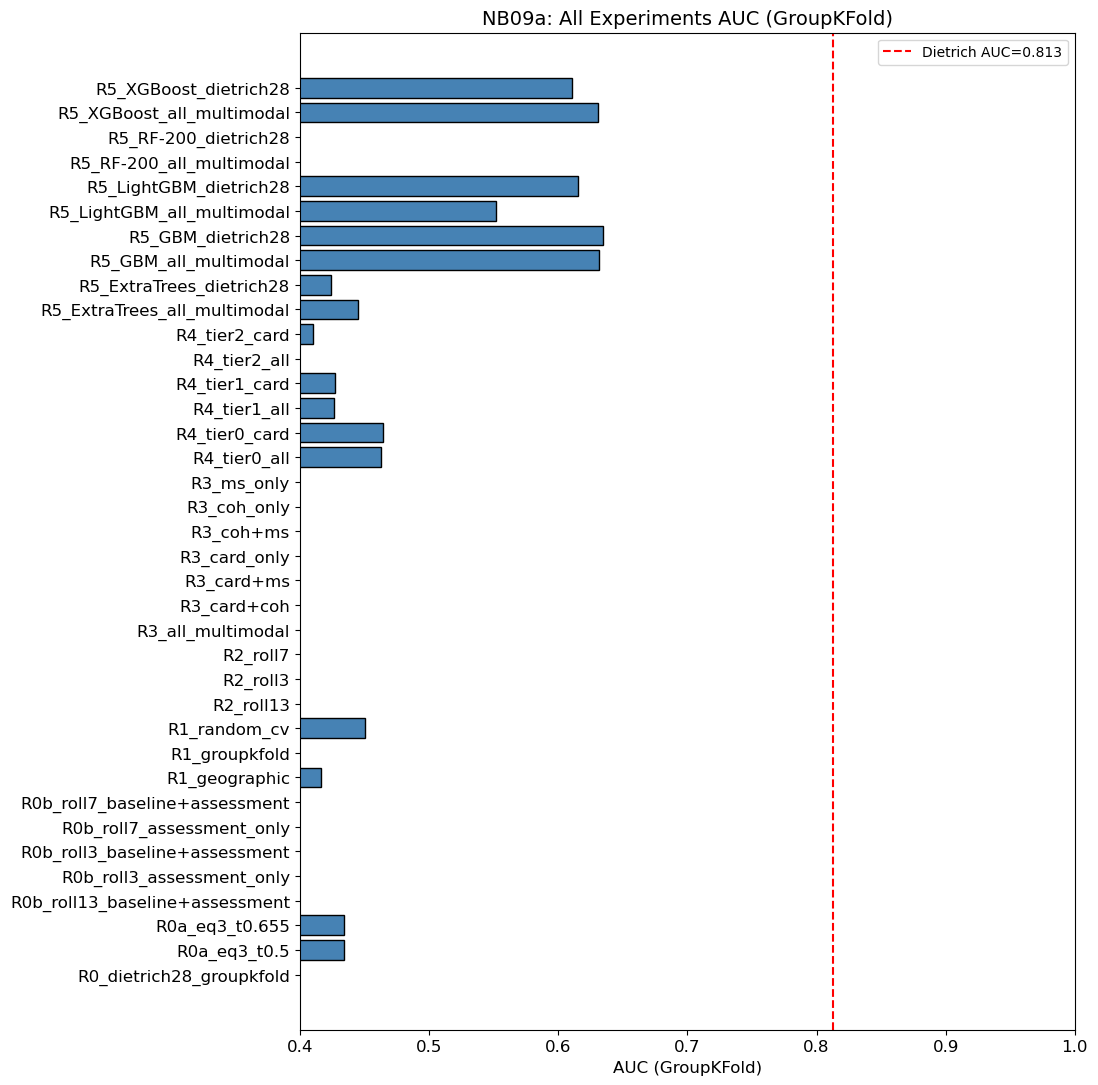

  Plot: cell_r6/all_experiments_auc_20260413_185007.png


In [13]:
# @title CELL R6: VALIDATION DIAGNOSTICS
import matplotlib.pyplot as plt

print("=" * 70)
print("CELL R6: VALIDATION DIAGNOSTICS")
print("=" * 70)

if not EXPERIMENT_LOG:
    print("  SKIP: no experiments logged yet")
else:
    # summary table
    print(f"\n  {'Experiment':45s} {'AUC':>6s} {'F1':>6s} {'P':>6s} {'R':>6s} {'nFeat':>6s}")
    print("  " + "-" * 75)
    for name, res in sorted(EXPERIMENT_LOG.items()):
        auc = res.get('auc_groupkfold', res.get('auc', 0))
        f1 = res.get('f1_groupkfold', 0)
        p = res.get('precision', 0)
        r = res.get('recall', 0)
        nf = res.get('n_features', 0)
        print(f"  {name:45s} {auc:6.3f} {f1:6.3f} {p:6.3f} {r:6.3f} {nf:6d}")

    # per-city AUC for best experiment
    best_exp = max(EXPERIMENT_LOG, key=lambda k: EXPERIMENT_LOG[k].get('auc_groupkfold', 0))
    best = EXPERIMENT_LOG[best_exp]
    if 'y_true' in best and 'groups' in best:
        print(f"\n  Per-city AUC breakdown ({best_exp}):")
        for city in sorted(np.unique(best['groups'])):
            mask = best['groups'] == city
            if len(np.unique(best['y_true'][mask])) > 1:
                city_auc = roc_auc_score(best['y_true'][mask], best['y_proba'][mask])
                print(f"    {city:25s} AUC={city_auc:.3f} (n={mask.sum()})")


    # AUC comparison bar chart
    import matplotlib.pyplot as plt
    exp_names = sorted(EXPERIMENT_LOG.keys())
    aucs = [EXPERIMENT_LOG[n].get('auc_groupkfold', 0) for n in exp_names]
    fig, ax = plt.subplots(figsize=(10, max(4, len(exp_names) * 0.35)))
    bars = ax.barh(exp_names, aucs, color='steelblue', edgecolor='black')
    ax.axvline(DIETRICH_PAPER['auc'], color='red', linestyle='--', linewidth=1.5, label=f"Dietrich AUC={DIETRICH_PAPER['auc']}")
    ax.set_xlabel('AUC (GroupKFold)')
    ax.set_xlim(0.4, 1.0)
    ax.legend()
    ax.set_title('NB09a: All Experiments AUC (GroupKFold)')
    save_fig(fig, 'all_experiments_auc', 'cell_r6')


# CELL R7: FEATURE IMPORTANCE + SHAP


In [14]:
# @title CELL R7: FEATURE IMPORTANCE + SHAP (bda_product_prepost)
from sklearn.inspection import permutation_importance
from stack_loader import get_feature_groups, get_ml_features

print("=" * 70)
print("CELL R7: FEATURE IMPORTANCE + SHAP")
print("=" * 70)

df = load_and_merge(PARQUET_PREPOST_TIER_FMT)
feature_groups = get_feature_groups(df)
all_cols = get_ml_features(df, exclude_groups=['meta', 'cloud_freq', 'obs_count', 'other'])

result = prepare_features(df, all_cols)
if result:
    X, y, groups, clean = result

    # train on all data for importance
    rf = RandomForestClassifier(**RF_PARAMS)
    rf.fit(X, y)

    # permutation importance on a holdout fold
    gkf = GroupKFold(n_splits=min(N_FOLDS, len(np.unique(groups))))
    for tr, te in gkf.split(X, y, groups):
        perm_imp = permutation_importance(rf, X[te], y[te], n_repeats=10,
                                           random_state=RANDOM_STATE, n_jobs=-1, scoring='roc_auc')
        break  # one fold is enough for importance ranking

    imp_df = pd.DataFrame({
        'feature': clean,
        'importance_mean': perm_imp.importances_mean,
        'importance_std': perm_imp.importances_std,
    }).sort_values('importance_mean', ascending=False)

    print(f"\n  Top-20 features (permutation importance):")
    for _, row in imp_df.head(20).iterrows():
        print(f"    {row['feature']:50s} {row['importance_mean']:.4f} +/- {row['importance_std']:.4f}")

    # SHAP (if available)
    try:
        import shap
        explainer = shap.TreeExplainer(rf)
        n_shap = min(2000, len(X))
        shap_values = explainer.shap_values(X[:n_shap])
        if isinstance(shap_values, list):
            shap_values = shap_values[1]  # class 1 (damaged)
        print(f"\n  SHAP computed on {n_shap} samples")
        shap.summary_plot(shap_values, X[:n_shap], feature_names=clean, show=True, max_display=20)
    except ImportError:
        print("\n  SHAP not available (pip install shap)")
    except Exception as e:
        print(f"\n  SHAP error: {e}")

del df
gc.collect()


CELL R7: FEATURE IMPORTANCE + SHAP
  load_tier_parquets: 3 tiers, 907371 rows


/home/alpineobotics/miniconda3/envs/bda/lib/python3.12/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/home/alpineobotics/miniconda3/envs/bda/lib/python3.12/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/home/alpineobotics/miniconda3/envs/bda/lib/python3.12/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. R


  Top-20 features (permutation importance):
    s2__composite__ndre__post_winter_baseline_std      0.0006 +/- 0.0015
    s1__vh__baseline__max_std                          0.0005 +/- 0.0016
    s2__composite__b08__prebattle_baseline_std         0.0005 +/- 0.0016
    s2__composite__b11__winter_baseline_std            0.0005 +/- 0.0017
    s1__vh__baseline__std_std                          0.0005 +/- 0.0017
    s2__composite__ndwi__post_winter_baseline_mean     0.0004 +/- 0.0017
    s2__composite__b8a__winter_baseline_max            0.0004 +/- 0.0018
    s2__composite__b12__post_winter_baseline_max       0.0004 +/- 0.0014
    s1__vh__baseline__mean_max                         0.0004 +/- 0.0016
    s1__vh__baseline__mean_mean                        0.0004 +/- 0.0017
    s1__vv__baseline__std_std                          0.0003 +/- 0.0014
    s2__composite__landuse__winter_baseline_mode       0.0003 +/- 0.0010
    s2__composite__ndwi__winter_baseline_mean          0.0003 +/- 0.0017
    s2

37

# CELL R8: SAVE OOF PREDICTIONS + SUMMARY


In [15]:
# @title CELL R8: SAVE OOF PREDICTIONS + SUMMARY

print("=" * 70)
print("CELL R8: SAVE OOF PREDICTIONS + SUMMARY")
print("=" * 70)

RESULTS_DIR = OUT_DIR  # already created in S0

# save experiment log
results_summary = {}
for name, res in EXPERIMENT_LOG.items():
    summary = {k: v for k, v in res.items() if k not in ('y_true', 'y_proba', 'y_pred', 'groups', 'fold_aucs', 'fold_f1s')}
    if 'fold_aucs' in res:
        summary['fold_aucs'] = [float(x) for x in res['fold_aucs']]
    results_summary[name] = summary

save_result(results_summary, 'experiment_log', 'cell_r8', fmt='json')

# save OOF predictions for NB09c stacking
for name, res in EXPERIMENT_LOG.items():
    if 'y_true' in res and 'y_proba' in res:
        oof_df = pd.DataFrame({
            'y_true': res['y_true'],
            'y_proba': res['y_proba'],
            'city': res['groups'],
        })
        oof_path = RESULTS_DIR / f'oof_{name}.parquet'
        oof_df.to_parquet(oof_path, index=False)

oof_count = sum(1 for r in EXPERIMENT_LOG.values() if 'y_true' in r)
print(f"  Saved: {oof_count} OOF prediction parquets")

# summary CSV
summary_rows = []
for name, res in sorted(EXPERIMENT_LOG.items(), key=lambda x: -x[1].get('auc_groupkfold', 0)):
    summary_rows.append({
        'experiment': name,
        'auc': res.get('auc_groupkfold', 0),
        'f1': res.get('f1_groupkfold', 0),
        'precision': res.get('precision', 0),
        'recall': res.get('recall', 0),
        'n_features': res.get('n_features', 0),
        'n_buildings': res.get('n_buildings', 0),
        'n_cities': res.get('n_cities', 0),
    })
if summary_rows:
    save_result(pd.DataFrame(summary_rows), 'experiment_summary', 'cell_r8')

# final summary
print(f"\n  {'Experiment':45s} {'AUC':>6s}")
print("  " + "-" * 55)
for name, res in sorted(EXPERIMENT_LOG.items(), key=lambda x: -x[1].get('auc_groupkfold', 0)):
    auc = res.get('auc_groupkfold', 0)
    print(f"  {name:45s} {auc:6.3f}")

print(f"\n  Dietrich paper: AUC={DIETRICH_PAPER['auc']}")
print(f"\n  Results saved to: {OUT_DIR}")


CELL R8: SAVE OOF PREDICTIONS + SUMMARY
  Saved: cell_r8/experiment_log_20260414_000944.json (16.7 KB)
  Saved: 33 OOF prediction parquets
  Saved: cell_r8/experiment_summary_20260414_000952.csv (3.6 KB)

  Experiment                                       AUC
  -------------------------------------------------------
  R5_GBM_dietrich28                              0.635
  R5_GBM_all_multimodal                          0.632
  R5_XGBoost_all_multimodal                      0.631
  R5_LightGBM_dietrich28                         0.615
  R5_XGBoost_dietrich28                          0.611
  R5_LightGBM_all_multimodal                     0.552
  R4_tier0_card                                  0.464
  R4_tier0_all                                   0.463
  R1_random_cv                                   0.450
  R5_ExtraTrees_all_multimodal                   0.445
  R0a_eq3_t0.5                                   0.434
  R0a_eq3_t0.655                                 0.434
  R4_tier1_card       

In [16]:
# @title CELL 19: SAVE REGISTRY
registry.save()


  SAVED: NB09a_experiments_20260412_230345.json (37 experiments)
  SAVED: NB09a_experiments_20260412_230345.csv


PosixPath('/content/drive_f/masterthesis/results/registry')